In [1]:
try:
    from google.colab import drive
    IN_COLAB = True
except Exception:
    IN_COLAB = False

if IN_COLAB:
    drive.mount("/content/drive")
    %cd /content/drive/MyDrive/NUIN/motion_CNN
    filepath = "/content/drive/MyDrive/NUIN/mouse_scenes/20210916_252MEA_mouse_right_half_ventral/fixationmovie_data.mat" 
    !git pull
else: 
  filepath =  "mouse_scenes/20210916_252MEA_mouse_right_half_ventral/fixationmovie_data.mat"
    

Mounted at /content/drive
/content/drive/MyDrive/NUIN/motion_CNN
Already up to date.


In [2]:
from utilities import CorrelationVelDataset, show_batch_frames, show_one_sample_summary, sample_animation, split_by_source_image, prerender_dataset_to_single_pt, TensorMovieDataset
from IPython.display import HTML, display
import torch.nn as nn
import torch.nn.functional as F
import torch
from torch.utils.data import Subset, DataLoader
import os 
import numpy as np
import matplotlib.pyplot as plt

# Set the resolution for figures displayed in the notebook
plt.rcParams['figure.dpi'] = 100

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")   
print(f"Using device: {device}")
print(os.getcwd())

Using device: cuda
/content/drive/MyDrive/NUIN/motion_CNN


In [4]:
dataset = CorrelationVelDataset(
    file = filepath,
    crop_hw=(400,400),
    downsample_hw=(50,50),
    frames_per_segment=75,
    fps = 75,
    samples_per_image= 8, 
    vel_std = (350,350),
    vel_corr=-0.0
    )

print("dataset length:", len(dataset))

dataset length: 2600


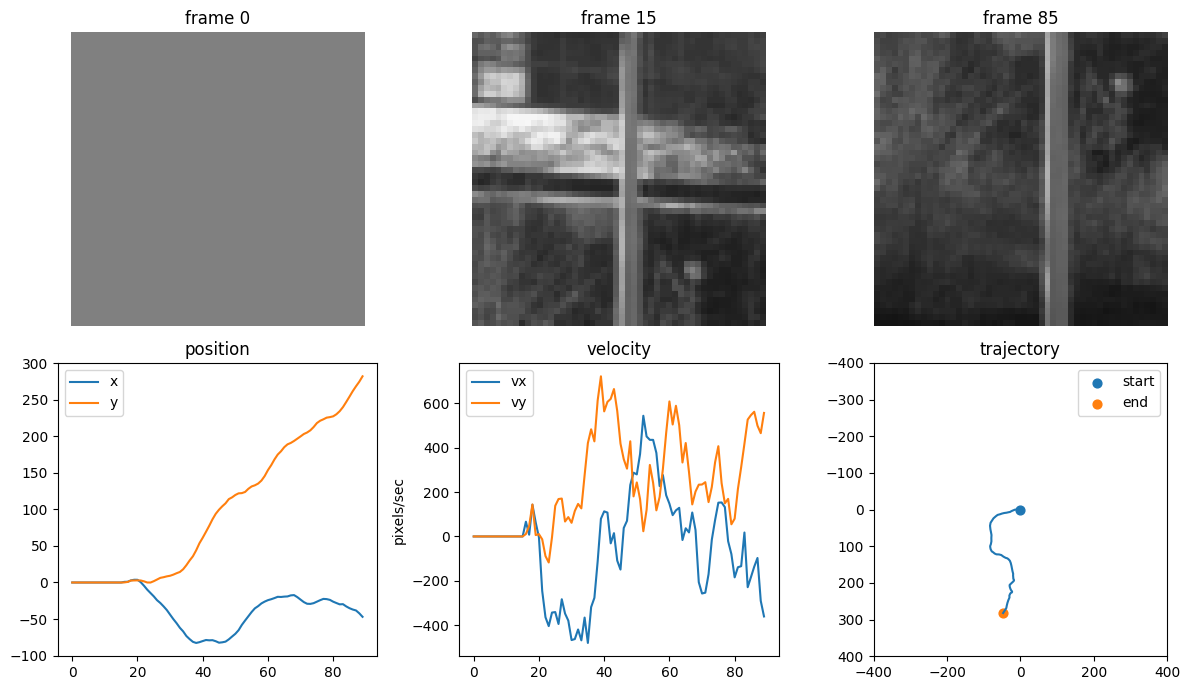

In [5]:
show_one_sample_summary(dataset, 0, frame_indices=[0,15,85])

In [6]:

# anim = sample_animation(dataset, 0, viz_fps=20, save_path=None)
# display(HTML(anim.to_jshtml()))

# Split/Val sets

In [7]:

train_dataset, val_dataset, train_keys, val_keys = split_by_source_image(
    dataset,
    train_frac=0.8,
    val_frac=0.2,
    seed=0,
)
print("Total samples:", len(dataset))
print("Train samples:", len(train_dataset))
print("Val samples:", len(val_dataset))

print("Train images:", len(train_keys))
print("Val images:", len(val_keys))

print("Overlap:", len(train_keys & val_keys))

Total samples: 2600
Train samples: 2080
Val samples: 520
Train images: 260
Val images: 65
Overlap: 0


In [8]:
cache_name_train = (
    f"corrvel_train_"
    f"hw{dataset.downsample_hw[0]}x{dataset.downsample_hw[1]}_"
    f"T{dataset.frames_per_segment}_"
    f"smp_img{dataset.samples_per_image}_"
    f"gray{dataset.gray_frames}_"
    f"std{dataset.vel_std}_"
    f"corr{dataset.vel_corr}_"
    f"seed{dataset.random_seed}.pt"
)

cache_name_val = (
    f"corrvel_val_"
    f"hw{dataset.downsample_hw[0]}x{dataset.downsample_hw[1]}_"
    f"T{dataset.frames_per_segment}_"
    f"smp_img{dataset.samples_per_image}_"
    f"gray{dataset.gray_frames}_"
    f"std{dataset.vel_std}_"
    f"corr{dataset.vel_corr}_"
    f"seed{dataset.random_seed}.pt"
)

train_cache = prerender_dataset_to_single_pt(
    dataset,
    train_dataset.indices,
    f"cache/{cache_name_train}",
    movie_dtype=torch.float16,
    overwrite=False,
)

val_cache = prerender_dataset_to_single_pt(
    dataset,
    val_dataset.indices,
    f"cache/{cache_name_val}",
    movie_dtype=torch.float16,
    overwrite=False,
)

Cache already exists, skipping render: cache/corrvel_train_hw50x50_T75_smp_img8_gray15_std(350, 350)_corr-0.0_seed0.pt
Cache already exists, skipping render: cache/corrvel_val_hw50x50_T75_smp_img8_gray15_std(350, 350)_corr-0.0_seed0.pt


In [9]:
cached_train = TensorMovieDataset(f"cache/{cache_name_train}", movie_dtype=torch.float32)
cached_val = TensorMovieDataset(f"cache/{cache_name_val}", movie_dtype=torch.float32)

train_loader = DataLoader(
    cached_train,
    batch_size=16,
    shuffle=True,
    num_workers=0,   # try 0 first; increase later
    pin_memory=True,
)

val_loader = DataLoader(
    cached_val,
    batch_size=16,
    shuffle=False,
    num_workers=0,
    pin_memory=True,
)

## Tiny CNN

In [10]:
class CNN(nn.Module):
    def __init__(self,
                 num_neurons=8,
                 height=50,
                 width=50,
                 rf_size_1=15,
                 rf_size_2=11,
                 max_delay=70,
                 num_subunits_1=8,
                 num_subunits_2=8,
                 initial_bias=1.0,
                 mean_function=F.softplus,
                 input_noise_std=0.0,
                 activity_noise_std=0.0,
                 dropout_p=0.0):

        super().__init__()

        self.num_neurons = num_neurons
        self.height = height
        self.width = width
        self.max_delay = max_delay
        self.rf_size_1 = rf_size_1
        self.rf_size_2 = rf_size_2
        self.num_subunits_1 = num_subunits_1
        self.num_subunits_2 = num_subunits_2
        self.mean_function = mean_function

        # Noise / regularization
        self.input_noise_std = input_noise_std
        self.activity_noise_std = activity_noise_std
        self.dropout = nn.Dropout(p=dropout_p)

        self.spatial_conv = nn.Conv2d(
            in_channels=1,
            out_channels=num_subunits_1,
            kernel_size=rf_size_1,
            padding=0,
            bias=True,
        )

        H1 = height - rf_size_1 + 1
        W1 = width - rf_size_1 + 1
        self.H1 = H1
        self.W1 = W1

        self.temporal_conv = nn.Conv1d(
            in_channels=num_subunits_1,
            out_channels=num_subunits_1,
            kernel_size=max_delay,
            groups=num_subunits_1,
            bias=True,
        )

        self.layer2 = nn.Conv2d(
            in_channels=num_subunits_1,
            out_channels=num_subunits_2,
            kernel_size=rf_size_2,
            padding=0,
            bias=True,
        )

        H2 = H1 - rf_size_2 + 1
        W2 = W1 - rf_size_2 + 1
        self.H2 = H2
        self.W2 = W2

        self.layer3 = nn.Linear(num_subunits_2, num_neurons)

        bias = torch.log(torch.exp(torch.tensor(float(initial_bias))) - 1.0)
        nn.init.constant_(self.layer3.bias, bias)

    def add_input_noise(self, movie):
        if self.training and self.input_noise_std > 0:
            movie = movie + self.input_noise_std * torch.randn_like(movie)

            # Optional if your movie is normalized to [0, 1]
            # movie = movie.clamp(0.0, 1.0)

        return movie

    def add_activity_noise(self, x):
        if self.training and self.activity_noise_std > 0:
            # Multiplicative noise. Keeps noise scale proportional to activity.
            noise = self.activity_noise_std * torch.randn_like(x)
            x = x * (1.0 + noise)

            # Since activations after ReLU should remain nonnegative
            x = torch.clamp(x, min=0.0)

        return x

    def forward(self, movie):
        """
        movie: (B, T, 1, H, W)
        returns: rates, shape (B, T, num_neurons)
        """

        movie = self.add_input_noise(movie)

        B, T, C, H, W = movie.shape

        # -------------------------------------------------------
        # 1. Spatial conv per frame
        # -------------------------------------------------------
        x = movie.reshape(B * T, C, H, W)
        x = self.spatial_conv(x)

        _, N1, H1, W1 = x.shape

        x = x.reshape(B, T, N1, H1, W1)

        # -------------------------------------------------------
        # 2. Temporal conv at each spatial location
        # -------------------------------------------------------
        x = x.permute(0, 3, 4, 2, 1)              # (B, H1, W1, N1, T)
        x = x.reshape(B * H1 * W1, N1, T)         # (B*H1*W1, N1, T)

        # causal temporal padding
        x = F.pad(x, (self.max_delay - 1, 0))
        x = self.temporal_conv(x)

        x = x.reshape(B, H1, W1, N1, T)
        x = x.permute(0, 4, 3, 1, 2)              # (B, T, N1, H1, W1)

        x = F.relu(x)
        x = self.add_activity_noise(x)

        # -------------------------------------------------------
        # 3. Second spatial conv
        # -------------------------------------------------------
        x = x.reshape(B * T, N1, H1, W1)
        x = self.layer2(x)
        x = F.relu(x)
        x = self.add_activity_noise(x)

        _, N2, H2, W2 = x.shape

        # -------------------------------------------------------
        # 4. Pooling over space + linear readout
        # -------------------------------------------------------
        x_pool = x.mean(dim=(-1, -2))              # (B*T, N2)

        # Optional dropout after pooling
        x_pool = self.dropout(x_pool)

        drive = self.layer3(x_pool)
        rates = self.mean_function(drive)

        rates = rates.reshape(B, T, self.num_neurons)

        return rates + 1e-8

In [11]:
class LinearVelocityDecoder(nn.Module):
    def __init__(self, num_neurons, out_dim=2):
        super().__init__()
        self.decoder = nn.Linear(num_neurons, out_dim)

        nn.init.normal_(self.decoder.weight, mean=0.0, std=0.1)
        nn.init.zeros_(self.decoder.bias)

    def forward(self, rates):
        return self.decoder(rates)
    
    
class RetinaVelocityModel(nn.Module):
    def __init__(self, retina, num_neurons):
        super().__init__()
        self.retina = retina
        self.decoder = LinearVelocityDecoder(num_neurons=num_neurons, out_dim=2)

    def forward(self, movie, return_rates=False):
        rates = self.retina(movie)          # (B, T, N), nonnegative
        pred_vel = self.decoder(rates)      # (B, T, 2), signed

        if return_rates:
            return rates, pred_vel

        return pred_vel

In [12]:
output_neurons = 6

retina = CNN(
    num_neurons=output_neurons,
    height=50,
    width=50,
    rf_size_1=9,
    rf_size_2=11,
    max_delay=15,
    num_subunits_1=5,
    num_subunits_2=6,
    initial_bias=1,
    mean_function=F.softplus,

    # noise / regularization
    input_noise_std=0.005,
    activity_noise_std=0.02,
    dropout_p=0.05,
)
model = RetinaVelocityModel(
    retina=retina,
    num_neurons=output_neurons,
).to(device)

In [13]:
from utilities import compute_velocity_stats, direct_velocity_loss
gray_frames = train_dataset.dataset.gray_frames

vel_mean, vel_std = compute_velocity_stats(
    train_dataset.dataset,
    indices=train_dataset.indices,
    device=device,
)

print("vel_mean:", vel_mean)
print("vel_std:", vel_std)

vel_mean: tensor([-1.0363, -3.6183], device='cuda:0')
vel_std: tensor([321.1669, 324.1007], device='cuda:0')


In [14]:
### Over fit a small dataset
batch = next(iter(train_loader))

movie = batch["movie"].to(device)
target = batch["scene_vel"].to(device)

# tiny = TinyMotionCNN(hidden=16).to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=0.0)

for step in range(300):
    pred = model(movie)

    loss = direct_velocity_loss(
        pred_vel_z=pred,
        target_vel=target,
        vel_mean=vel_mean,
        vel_std=vel_std,
        gray_frames=gray_frames,
    )

    optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer.step()

    if step % 25 == 0:
        print(step, loss.item())

0 1.0197190046310425
25 1.001356840133667
50 0.9871129393577576
75 0.9670906662940979
100 0.9483520984649658
125 0.907477617263794
150 0.8931370377540588
175 0.8652809858322144
200 0.8118414282798767
225 0.7375938892364502
250 0.733436107635498
275 0.6971559524536133


## Train tiny CNN in whole dataset

In [15]:
print("train batches per epoch:", len(train_loader))
print("val batches per epoch:", len(val_loader))
print("train samples:", len(train_loader.dataset))
print("val samples:", len(val_loader.dataset))

train batches per epoch: 130
val batches per epoch: 33
train samples: 2080
val samples: 520


In [36]:
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
### BEST PERFORMING MODEL SO FAR (6 neurons, RFs: 9 and 11, 
#                               subunits 5 and 6, 15 delay)
# dropout 0.02, input noise 0.005, activity noise 0.02, initial bias 1.0
output_neurons = 6

retina = CNN(
    num_neurons=output_neurons,
    height=50,
    width=50,
    rf_size_1=9,
    rf_size_2=11,
    max_delay=15,
    num_subunits_1=5,
    num_subunits_2=6,
    initial_bias=1.0,
    mean_function=F.softplus,

    # noise / regularization
    input_noise_std=0.02,
    activity_noise_std=0.02,
    dropout_p=0.00,
)

model = RetinaVelocityModel(
    retina=retina,
    num_neurons=output_neurons,
).to(device)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-4,
)

history = {
    "train_loss": [],
    "val_loss": [],
}


def run_epoch_direct(
    model,
    loader,
    optimizer=None,
    vel_mean=None,
    vel_std=None,
    gray_frames=15,
    device="cpu",
    desc="",
):
    is_train = optimizer is not None
    model.train(is_train)

    total_loss = 0.0
    total_n = 0

    pbar = tqdm(loader, desc=desc, leave=False)

    for batch in pbar:
        movie = batch["movie"].to(device)
        target = batch["scene_vel"].to(device)

        pred = model(movie)

        loss = direct_velocity_loss(
            pred_vel_z=pred,
            target_vel=target,
            vel_mean=vel_mean,
            vel_std=vel_std,
            gray_frames=gray_frames,
        )

        if is_train:
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

        B = movie.shape[0]
        total_loss += loss.item() * B
        total_n += B

        # pbar.set_postfix({"vel": total_loss / total_n})

    return total_loss / total_n


num_epochs = 200

for epoch in range(1, num_epochs + 1):
    train_loss = run_epoch_direct(
        model,
        train_loader,
        optimizer=optimizer,
        vel_mean=vel_mean,
        vel_std=vel_std,
        gray_frames=gray_frames,
        device=device,
        desc=f"Tiny instant epoch {epoch:03d} train",
    )

    with torch.no_grad():
        val_loss = run_epoch_direct(
            model,
            val_loader,
            optimizer=None,
            vel_mean=vel_mean,
            vel_std=vel_std,
            gray_frames=gray_frames,
            device=device,
            desc=f"Tiny instant epoch {epoch:03d} val",
        )

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    if epoch == 1 or epoch % 10 == 0 or epoch == num_epochs:
        print(f"Epoch {epoch:03d} | train {train_loss:.4f} | val {val_loss:.4f}")

Tiny instant epoch 001 train:   0%|          | 0/130 [00:00<?, ?it/s]

Tiny instant epoch 001 val:   0%|          | 0/33 [00:00<?, ?it/s]

Epoch 001 | train 1.0167 | val 0.9647


Tiny instant epoch 002 train:   0%|          | 0/130 [00:00<?, ?it/s]

Tiny instant epoch 002 val:   0%|          | 0/33 [00:00<?, ?it/s]

...

Tiny instant epoch 199 train:   0%|          | 0/130 [00:00<?, ?it/s]

Tiny instant epoch 199 val:   0%|          | 0/33 [00:00<?, ?it/s]

Tiny instant epoch 200 train:   0%|          | 0/130 [00:00<?, ?it/s]

Tiny instant epoch 200 val:   0%|          | 0/33 [00:00<?, ?it/s]

Epoch 200 | train 0.0412 | val 0.0358


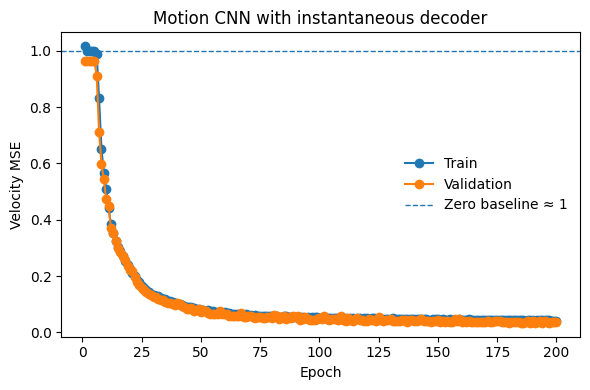

In [37]:
epochs = range(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(6, 4))
plt.plot(epochs, history["train_loss"], marker="o", label="Train")
plt.plot(epochs, history["val_loss"], marker="o", label="Validation")
plt.axhline(1.0, linestyle="--", linewidth=1, label="Zero baseline ≈ 1")
plt.xlabel("Epoch")
plt.ylabel("Velocity MSE")
plt.title("Motion CNN with instantaneous decoder")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

In [38]:
import numpy as np
import torch
import matplotlib.pyplot as plt


@torch.no_grad()
def compute_val_r2_per_movie(
    model,
    val_loader,
    vel_mean,
    vel_std,
    gray_frames,
    device,
):
    model.eval()

    r2_per_seq = []
    pred_all = []
    target_all = []

    for batch in val_loader:
        movie = batch["movie"].to(device)
        target = batch["scene_vel"].to(device)  # raw px/s, (B, T, 2)

        pred_z = model(movie)                   # normalized, (B, T, 2)
        pred = pred_z * vel_std + vel_mean      # back to px/s

        pred = pred[:, gray_frames:, :]
        target = target[:, gray_frames:, :]

        # Per movie R² over both vx and vy together
        ss_res = ((target - pred) ** 2).sum(dim=(1, 2))
        target_mean = target.mean(dim=(1, 2), keepdim=True)
        ss_tot = ((target - target_mean) ** 2).sum(dim=(1, 2))

        r2 = 1.0 - ss_res / (ss_tot + 1e-8)

        r2_per_seq.extend(r2.detach().cpu().numpy())
        pred_all.append(pred.detach().cpu())
        target_all.append(target.detach().cpu())

    r2_per_seq = np.asarray(r2_per_seq)
    pred_all = torch.cat(pred_all, dim=0)        # (Nval, T-gray, 2)
    target_all = torch.cat(target_all, dim=0)

    return r2_per_seq, pred_all, target_all

r2_per_seq, pred_val, target_val = compute_val_r2_per_movie(
    model=model,
    val_loader=val_loader,
    vel_mean=vel_mean,
    vel_std=vel_std,
    gray_frames=gray_frames,
    device=device,
)

mean_r2 = np.mean(r2_per_seq)
sem_r2 = np.std(r2_per_seq, ddof=1) / np.sqrt(len(r2_per_seq))

print("Mean R²:", mean_r2)
print("SEM R²:", sem_r2)
print("N validation movies:", len(r2_per_seq))
print("Min/Max R²:", r2_per_seq.min(), r2_per_seq.max())

Mean R²: 0.9494084
SEM R²: 0.0015328138913395584
N validation movies: 520
Min/Max R²: 0.67501175 0.9867763


/tmp/ipykernel_831/3064212615.py:144: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


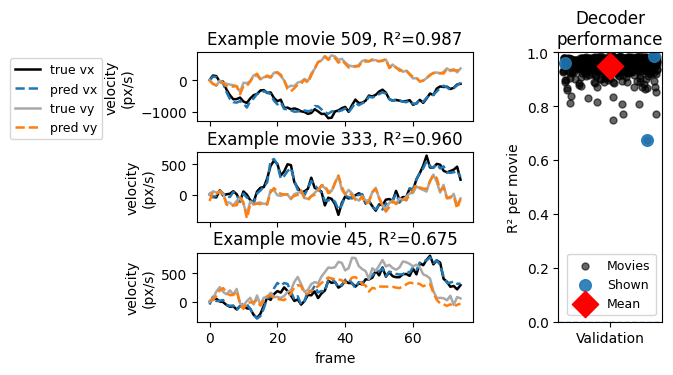

In [39]:
from matplotlib.gridspec import GridSpec


def plot_validation_summary_two_columns(
    r2_per_seq,
    pred_val,
    target_val,
    n_examples=3,
    example_mode="best",  # "best", "worst", or "mixed"
    figsize=(11, 7),
):
    # Convert tensors to numpy if needed
    if hasattr(pred_val, "detach"):
        pred_val_np = pred_val.detach().cpu().numpy()
    else:
        pred_val_np = np.asarray(pred_val)

    if hasattr(target_val, "detach"):
        target_val_np = target_val.detach().cpu().numpy()
    else:
        target_val_np = np.asarray(target_val)

    r2_per_seq = np.asarray(r2_per_seq)

    # Choose example indices
    order = np.argsort(r2_per_seq)

    if example_mode == "best":
        example_idxs = order[-n_examples:][::-1]
    elif example_mode == "worst":
        example_idxs = order[:n_examples]
    elif example_mode == "mixed":
        example_idxs = np.array([
            order[-1],
            order[len(order) // 2],
            order[0],
        ])
        example_idxs = example_idxs[:n_examples]
    else:
        raise ValueError("example_mode must be 'best', 'worst', or 'mixed'.")

    mean_r2 = np.mean(r2_per_seq)
    sem_r2 = np.std(r2_per_seq, ddof=1) / np.sqrt(len(r2_per_seq))

    # Figure layout
    fig = plt.figure(figsize=figsize)
    gs = GridSpec(
        nrows=len(example_idxs),
        ncols=2,
        width_ratios=[3.2, 1.2],
        wspace=0.45,
        hspace=0.45,
        figure=fig,
    )

    # -----------------------------
    # Left column: example traces
    # -----------------------------
    for row, idx in enumerate(example_idxs):
        ax = fig.add_subplot(gs[row, 0])

        pred = pred_val_np[idx]
        target = target_val_np[idx]

        t = np.arange(target.shape[0])

        ax.plot(t, target[:, 0], label="true vx", linewidth=1.8, c='k')
        ax.plot(t, pred[:, 0], label="pred vx", linewidth=1.8, linestyle="--")

        ax.plot(t, target[:, 1], label="true vy", linewidth=1.8, c='darkgray')
        ax.plot(t, pred[:, 1], label="pred vy", linewidth=1.8, linestyle="--")

        ax.set_title(f"Example movie {idx}, R²={r2_per_seq[idx]:.3f}")
        ax.set_ylabel("velocity\n(px/s)")

        if row == len(example_idxs) - 1:
            ax.set_xlabel("frame")
        else:
            ax.set_xticklabels([])

        if row == 0:
            ax.legend(ncol=1, fontsize=9, loc="upper left",
                      bbox_to_anchor=(-.7, 1.0),)

    # -----------------------------
    # Right column: R² scatter plot
    # -----------------------------
    ax_r2 = fig.add_subplot(gs[:, 1])

    x0 = 0
    rng = np.random.default_rng(0)
    x_jitter = x0 + rng.uniform(-0.15, 0.15, size=len(r2_per_seq))

    ax_r2.scatter(
        x_jitter,
        r2_per_seq,
        alpha=0.6,
        s=25,
        c="k",
        label="Movies",
    )

    # Highlight selected examples
    ax_r2.scatter(
        x_jitter[example_idxs],
        r2_per_seq[example_idxs],
        alpha=0.9,
        s=70,
        c="tab:blue",
        label="Shown",
    )

    # Mean marker + SEM
    ax_r2.scatter(
        x0,
        mean_r2,
        s=180,
        marker="D",
        c="red",
        label="Mean",
        zorder=5,
    )

    ax_r2.errorbar(
        x0,
        mean_r2,
        yerr=sem_r2,
        fmt="none",
        ecolor="red",
        capsize=5,
        linewidth=2,
        zorder=4,
    )

    ax_r2.axhline(0, linestyle="--", linewidth=1)
    ax_r2.set_xticks([x0])
    ax_r2.set_xticklabels(["Validation"])
    ax_r2.set_ylim(0, 1)
    ax_r2.set_ylabel("R² per movie")
    ax_r2.set_title("Decoder\nperformance")
    ax_r2.legend(fontsize=9, loc="lower right")

    # fig.suptitle("Validation performance summary", y=1.02, fontsize=14)
    plt.tight_layout()
    plt.show()

    return fig

fig = plot_validation_summary_two_columns(
    r2_per_seq=r2_per_seq,
    pred_val=pred_val,
    target_val=target_val,
    n_examples=3,
    example_mode="mixed",
    figsize=(6, 3.5),
)

In [47]:

def plot_cnn_subunits_1(cnn: nn.Module):
    """
    Plot the first layer of subunits of a CNN.
    """
    num_subunits = cnn.num_subunits_1
    max_delay = cnn.max_delay

    fig, axs = plt.subplots(num_subunits, 3, figsize=(8, 4 * num_subunits),
                            gridspec_kw=dict(width_ratios=[1, 1.9, .1]))

    temporal_weights = cnn.temporal_conv.weight[:, 0].to("cpu").detach()
    bias = cnn.temporal_conv.bias.to("cpu").detach()
    spatial_weights = cnn.spatial_conv.weight.to("cpu").detach()
    spatial_weights = spatial_weights[:, 0, :, :]

    # normalize and flip the spatial weights
    for n in range(num_subunits):
        # Flip if spatial weight peak is negative
        if torch.allclose(spatial_weights[n].min(),
                    -abs(spatial_weights[n]).max()):
            spatial_weights[n] = -spatial_weights[n]
            temporal_weights[n] = -temporal_weights[n]

        # Normalize
        scale = torch.linalg.norm(spatial_weights[n])
        spatial_weights[n] /= scale
        temporal_weights[n] *= scale

    # Set the same limits for each neuron
    vlim = abs(spatial_weights).max()
    ylim = abs(temporal_weights).max()

    for n in range(num_subunits):
        axs[n, 0].plot(torch.arange(-max_delay+1, 1) * 10, temporal_weights[n])
        axs[n, 0].set_ylim(-ylim, ylim)
        axs[n, 0].plot(torch.arange(-max_delay+1, 1) * 10, torch.zeros(max_delay), ':k')
        if n < num_subunits - 1:
            axs[n, 0].set_xticklabels([])
        else:
            axs[n, 0].set_xlabel("$\Delta t$ [ms]")

        im = axs[n, 1].imshow(spatial_weights[n],
                              vmin=-vlim, vmax=vlim, cmap="RdBu_r")
        axs[n, 1].set_axis_off()
        axs[n, 1].set_title("subunit 1,{}".format(n + 1))
        plt.colorbar(im, cax=axs[n, 2])

def plot_cnn_subunits2(cnn: nn.Module):
    """
    Plot the second layer of subunits of a CNN.
    """
    cnn_filters_2 = cnn.layer2.weight.to("cpu").detach()

    fig, axs = plt.subplots(cnn.num_subunits_2,
                            cnn.num_subunits_1,
                            figsize=(4 * cnn.num_subunits_2,
                                    4 * cnn.num_subunits_1),
                            sharex=True, sharey=True)
    # vlim = abs(cnn_filters_2).max()
    percentile = 99
    vlim = torch.quantile(cnn_filters_2.abs().flatten(), percentile / 100).item()
    for i in range(cnn.num_subunits_2):
        for j in range(cnn.num_subunits_1):
            axs[i, j].imshow(cnn_filters_2[i, j],
                            vmin=-vlim, vmax=vlim, cmap="RdBu_r")

            axs[i, j].set_title('subunit 1,{} $\\to$ 2,{}'.format(j+1,i+1))


<>:40: SyntaxWarning: invalid escape sequence '\D'
<>:40: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_831/2687534890.py:40: SyntaxWarning: invalid escape sequence '\D'
  axs[n, 0].set_xlabel("$\Delta t$ [ms]")


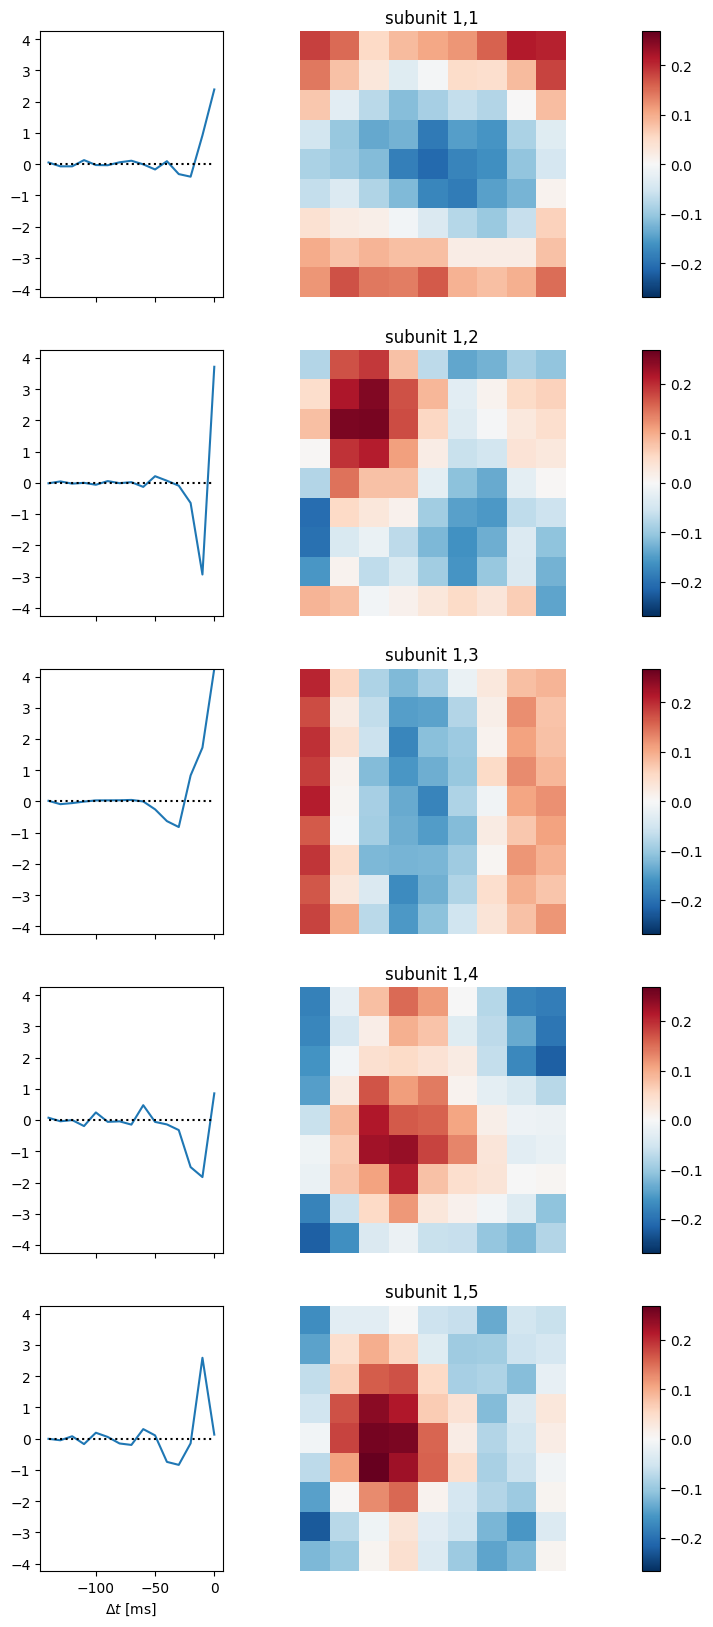

In [48]:
plot_cnn_subunits_1(retina)

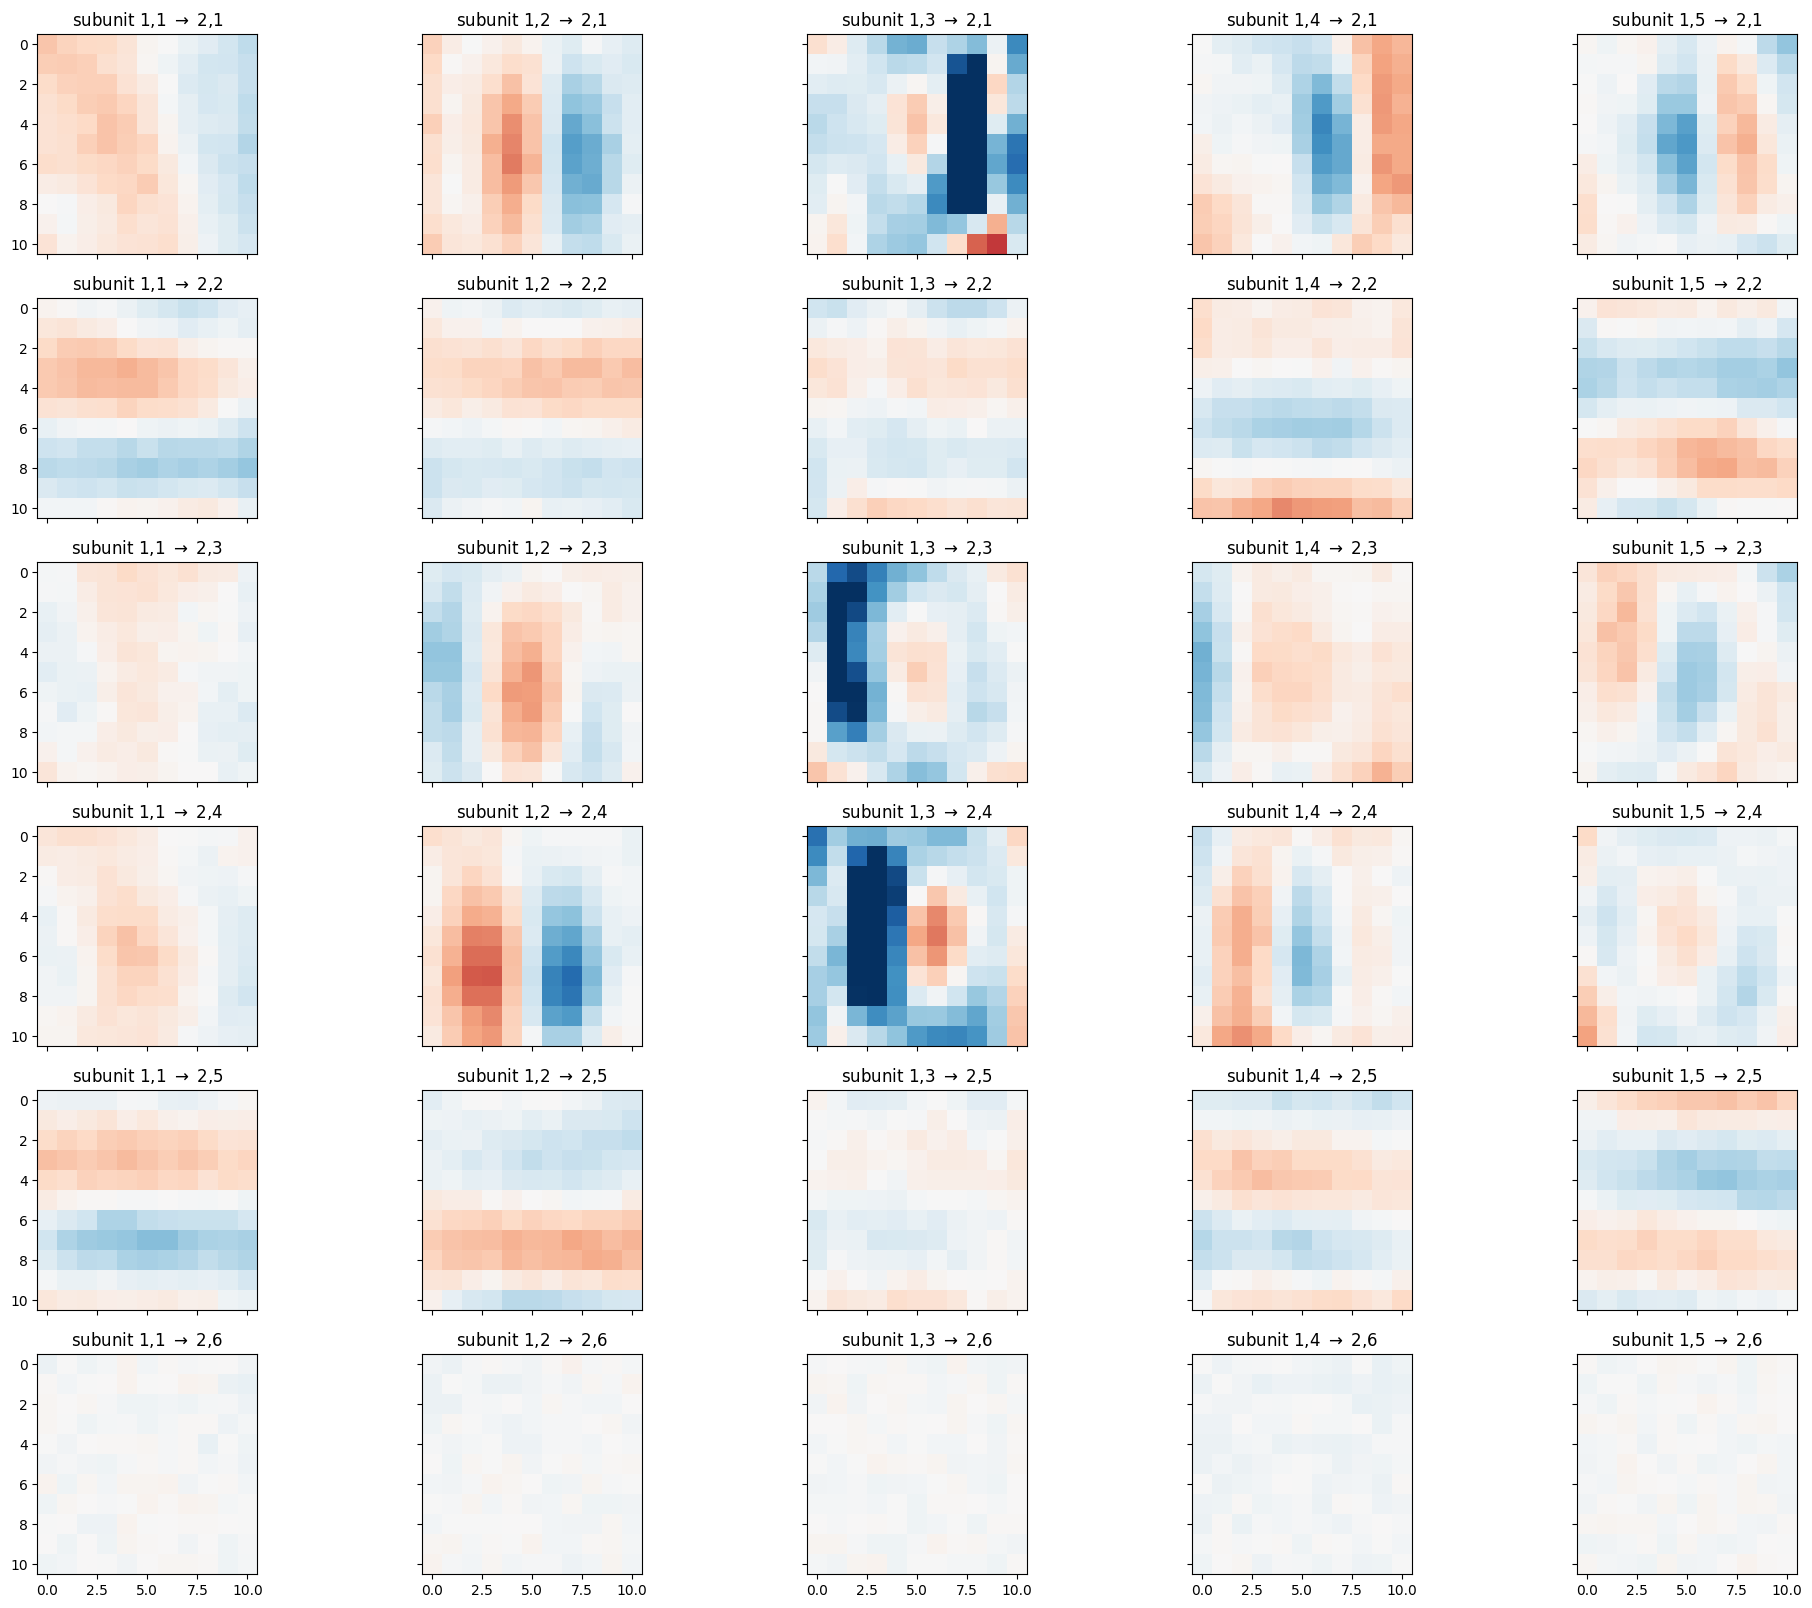

In [49]:
plot_cnn_subunits2(retina)

In [50]:
@torch.no_grad()
def rate_velocity_correlations(model, loader, vel_mean, vel_std, device):
    model.eval()

    all_rates = []
    all_vel = []

    for batch in loader:
        movie = batch["movie"].to(device)
        vel = batch["scene_vel"].to(device)

        rates, pred = model(movie, return_rates=True)  # (B,T,N), (B,T,2)

        all_rates.append(rates.detach().cpu())
        all_vel.append(vel.detach().cpu())

    R = torch.cat(all_rates, dim=0).reshape(-1, all_rates[0].shape[-1]).numpy()
    V = torch.cat(all_vel, dim=0).reshape(-1, 2).numpy()

    # optionally z-score velocity using training stats
    Vz = (V - vel_mean.cpu().numpy()) / vel_std.cpu().numpy()

    corrs = []
    for i in range(R.shape[1]):
        ri = R[:, i]
        cx = np.corrcoef(ri, Vz[:, 0])[0, 1]
        cy = np.corrcoef(ri, Vz[:, 1])[0, 1]
        corrs.append([cx, cy])

    return np.array(corrs)

corr = rate_velocity_correlations(model, val_loader, vel_mean, vel_std, device)

angles = np.arctan2(corr[:, 1], corr[:, 0])
strength = np.linalg.norm(corr, axis=1)

for i, (ang, s) in enumerate(zip(angles, strength)):
    print(f"unit {i}: angle={np.degrees(ang):.1f} deg, strength={s:.3f}")

unit 0: angle=93.3 deg, strength=0.260
unit 1: angle=-90.9 deg, strength=0.862
unit 2: angle=-177.3 deg, strength=0.423
unit 3: angle=-1.1 deg, strength=0.913
unit 4: angle=65.3 deg, strength=0.577
unit 5: angle=-88.7 deg, strength=0.225


In [51]:
W = model.decoder.decoder.weight.detach().cpu().numpy()  # (2, N)

for i in range(W.shape[1]):
    wx, wy = W[0, i], W[1, i]
    angle = np.degrees(np.arctan2(wy, wx))
    mag = np.sqrt(wx**2 + wy**2)
    print(f"unit {i}: decoder angle={angle:.1f} deg, magnitude={mag:.3f}")

unit 0: decoder angle=89.7 deg, magnitude=1.361
unit 1: decoder angle=-85.6 deg, magnitude=0.340
unit 2: decoder angle=177.5 deg, magnitude=0.378
unit 3: decoder angle=-1.1 deg, magnitude=0.718
unit 4: decoder angle=63.7 deg, magnitude=0.138
unit 5: decoder angle=-90.8 deg, magnitude=1.119


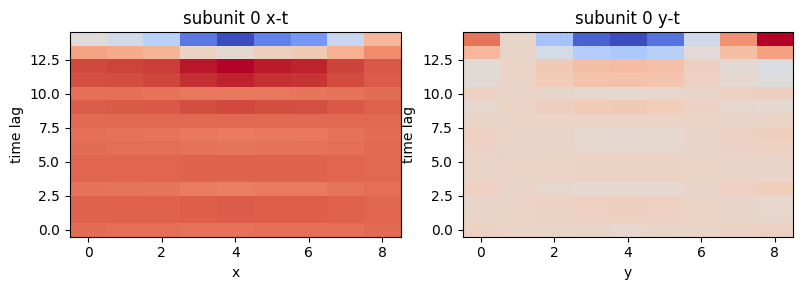

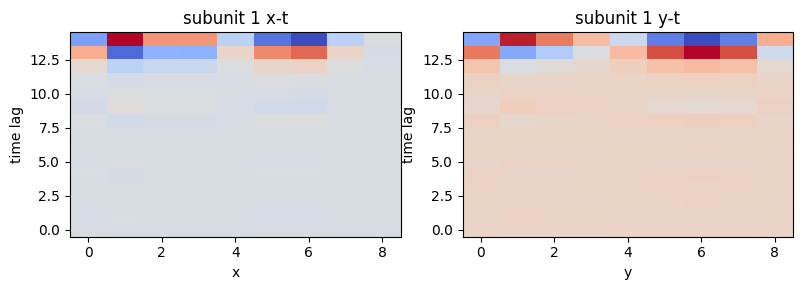

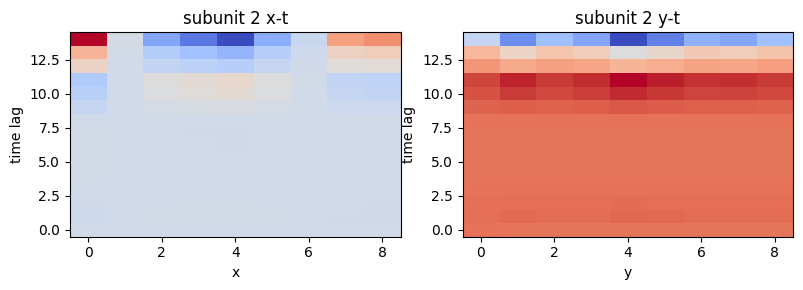

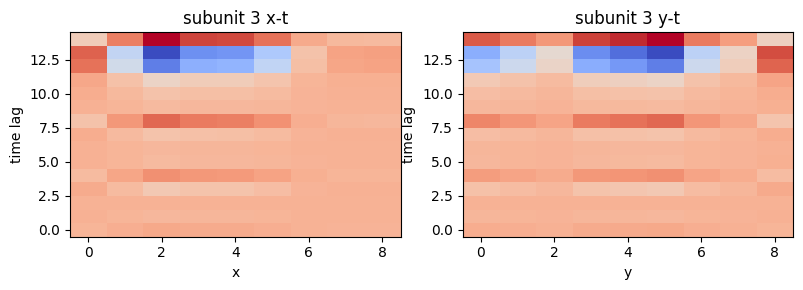

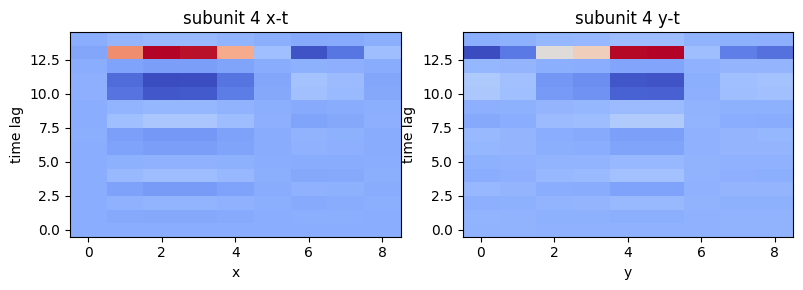

In [52]:
def plot_effective_xt_yt(cnn, subunit_idx, center_y=None, center_x=None):
    temporal = cnn.temporal_conv.weight[subunit_idx, 0].detach().cpu().numpy()
    spatial = cnn.spatial_conv.weight[subunit_idx, 0].detach().cpu().numpy()

    # effective filter: (T,H,W)
    K = temporal[:, None, None] * spatial[None, :, :]

    T, H, W = K.shape
    if center_y is None:
        center_y = H // 2
    if center_x is None:
        center_x = W // 2

    xt = K[:, center_y, :]  # (T,W)
    yt = K[:, :, center_x]  # (T,H)

    fig, axs = plt.subplots(1, 2, figsize=(8, 3))
    axs[0].imshow(xt, aspect="auto", origin="lower", cmap="coolwarm")
    axs[0].set_title(f"subunit {subunit_idx} x-t")
    axs[0].set_xlabel("x")
    axs[0].set_ylabel("time lag")

    axs[1].imshow(yt, aspect="auto", origin="lower", cmap="coolwarm")
    axs[1].set_title(f"subunit {subunit_idx} y-t")
    axs[1].set_xlabel("y")
    axs[1].set_ylabel("time lag")

    plt.tight_layout()
    plt.show()

for idx in range(retina.num_subunits_1):
    plot_effective_xt_yt(retina, idx)